# V768 - Measuring Vision with Psychophysics

## Lab 10 - 3D Motion Direction Estimation

In this lab, we return to motion direction estimation, but now in the *xz* plane. Rather than estimating the direction of a dot field moving across a flat screen, you will view a 3D dot cloud moving through depth: toward you, away from you, and to the left or right. You will report the direction of motion as seen from above using a line indicator.

After collecting data, we will examine how accurately you estimated different directions. Some directions—those that are purely lateral—are relatively straightforward to estimate. Others, which include motion in depth, require the visual system to recover depth motion from subtle differences between the two eyes’ retinal images. We will then compare your 3D estimation performance to 2D data from Lab 7 to see where these limits show up most clearly.

### Learning Outcomes

1. Visualize and interpret 3D motion direction estimation data, identifying which directions (lateral vs. in-depth) are estimated more or less accurately.
2. Explain why estimating motion direction in 3D is inherently more ambiguous than in 2D, based on the geometry of how 3D motion projects onto the retina.

### Questions

1. Include and write a caption for the error-by-direction figure in Part A, Step 3.
2. Explain which directions you expect to be hardest to estimate and whether your data line up with that expectation.
3. Include and write a caption for the final figure in Part B.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def circular_mean(degrees):
    """Circular mean of angles in degrees, expressed on [0, 360)."""
    radians = np.deg2rad(np.asarray(degrees, dtype=float))
    return float(np.mod(np.rad2deg(np.angle(np.sum(np.exp(1j * radians)))), 360))


def find_participant_files(data_dir, participant_id):
    data_dir = Path(data_dir)
    if not data_dir.exists():
        raise FileNotFoundError(
            "PsychoPy data folder not found. Try changing your current Python "
            "folder to the folder containing this notebook."
        )
    paths = sorted(path for path in data_dir.glob(f"{participant_id}*.csv")
                   if path.name.startswith(participant_id))
    if not paths:
        raise FileNotFoundError("No files found.")
    info = pd.DataFrame({
        "name": [path.name for path in paths],
        "folder": [str(path.parent) for path in paths],
        "path": paths,
    })
    print("data files found:")
    for name in info["name"]:
        print(f'    "{name}"')
    return info


def load_psychopy_csvs(file_info, remove_instruction_rows=False):
    frames = []
    for path in file_info["path"]:
        frame = pd.read_csv(path)
        if remove_instruction_rows:
            if "thisN" in frame:
                frame = frame[frame["thisN"].notna()]
            elif "trials.thisN" in frame:
                frame = frame[frame["trials.thisN"].notna()]
            else:
                frame = frame.iloc[1:]
        frames.append(frame.reset_index(drop=True))
    return pd.concat(frames, ignore_index=True)


def format_mae_axis(ax, title, ymax=None):
    ax.set_xlabel("stimulus direction (deg)")
    ax.set_ylabel("mean absolute error (deg)")
    ax.set_title(title)
    ax.set_xticks([0, 90, 180, 270, 360])
    ax.set_xticklabels(["0° (right)", "90° (away)", "180° (left)", "270° (toward)", "360°"])
    ax.set_xlim(0, 360)
    if ymax is not None:
        ax.set_ylim(0, ymax)

## Part A. 3D Motion Direction Estimation

### Step 1. Data collection

Open `3d-motion-direction-estimation-xy-indicator.py` in the `3d-motion-direction-estimation` folder and run the experiment. Put on your red-cyan anaglyph glasses (red filter over the left eye, cyan filter over the right eye). A run includes **144 trials**; try to complete two runs.

### Step 2. Load your data

Enter the participant ID used in the experiment.

In [2]:
participant_id = "demo"

data_dir = Path("3d-motion-direction-estimation") / "data"
file_info = find_participant_files(data_dir, participant_id)
n_files = len(file_info)

data files found:
    "demo_3d-motion-direction-estimation_2026-04-08_20h53.15.214.csv"


**Confirm that your data files are listed above.** There should be one file.

#### Load and merge data tables

In [3]:
estim3d_data = load_psychopy_csvs(file_info)
n_trials = len(estim3d_data)
print(f"number of trials = {n_trials}")

number of trials = 144


### Step 3. Analyze the data

The stimulus was a cloud of 3D dots rendered as a red-cyan anaglyph. Dots moved in the *xz* plane—left/right and toward/away from you—and appeared to the left or right of fixation. The file records `direction_presented_deg` (0° = rightward, 90° = away, 180° = leftward, 270° = toward), `response_direction_deg`, `direction_error_deg`, and stimulus `side`.

In [4]:
stim_direction_3d = estim3d_data["direction_presented_deg"].astype(float)
response_direction_3d = estim3d_data["response_direction_deg"].astype(float)
error_3d = estim3d_data["direction_error_deg"].astype(float)
side = estim3d_data["side"].astype(str)

#### Visualize the response per trial

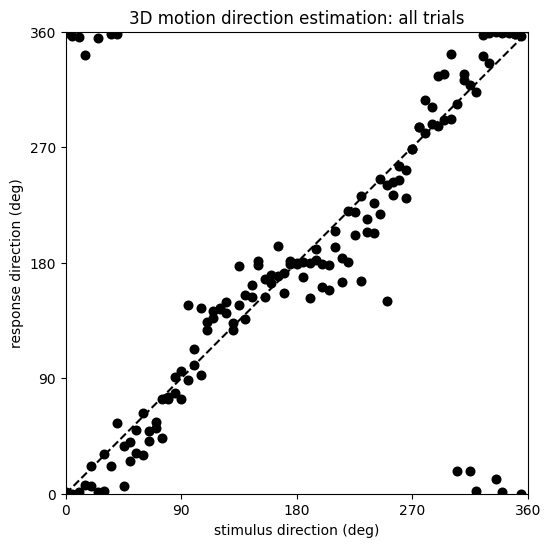

In [5]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(stim_direction_3d, response_direction_3d, color="black", linewidths=1.2)
ax.plot([0, 360], [0, 360], "k--", linewidth=1.5)
ax.set(xlabel="stimulus direction (deg)", ylabel="response direction (deg)",
       title="3D motion direction estimation: all trials", xlim=(0, 360), ylim=(0, 360))
ax.set_xticks(np.arange(0, 361, 90)); ax.set_yticks(np.arange(0, 361, 90))
ax.set_aspect("equal", adjustable="box")
plt.show()

#### Determine average response per direction

In [6]:
results_3d = (
    pd.DataFrame({"direction": stim_direction_3d, "response": response_direction_3d})
    .groupby("direction", as_index=False)
    .agg(n_trials=("response", "size"), mean_response=("response", circular_mean))
)
display(results_3d)

,direction,n_trials,mean_response
0,0.0,2,0.193052
1,5.0,2,358.507631
2,10.0,2,358.339492
3,15.0,2,354.560358
4,20.0,2,13.895493
...,...,...,...
67,335.0,2,5.621791
68,340.0,2,0.172763
69,345.0,2,359.365531
70,350.0,2,357.946406


#### Plot average response as a function of stimulus direction

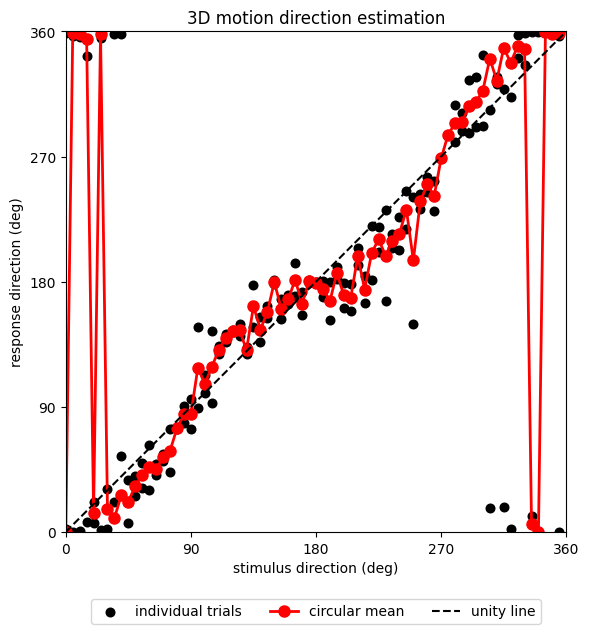

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(stim_direction_3d, response_direction_3d, color="black", linewidths=1.2, label="individual trials")
ax.plot(results_3d["direction"], results_3d["mean_response"], "r.-", markersize=16, linewidth=2, label="circular mean")
ax.plot([0, 360], [0, 360], "k--", linewidth=1.5, label="unity line")
ax.set(xlabel="stimulus direction (deg)", ylabel="response direction (deg)",
       title="3D motion direction estimation", xlim=(0, 360), ylim=(0, 360))
ax.set_xticks(np.arange(0, 361, 90)); ax.set_yticks(np.arange(0, 361, 90))
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3)
plt.show()

#### Error as a function of stimulus direction

The plots above show the overall response pattern. To see where errors are largest, compute the **mean absolute error** at each stimulus direction. Lateral directions (near 0° and 180°) produce a large, symmetric signal on both retinas. In-depth directions (near 90° and 270°) require recovery of motion-in-depth from small differences in the two retinal images—a weaker and noisier cue.

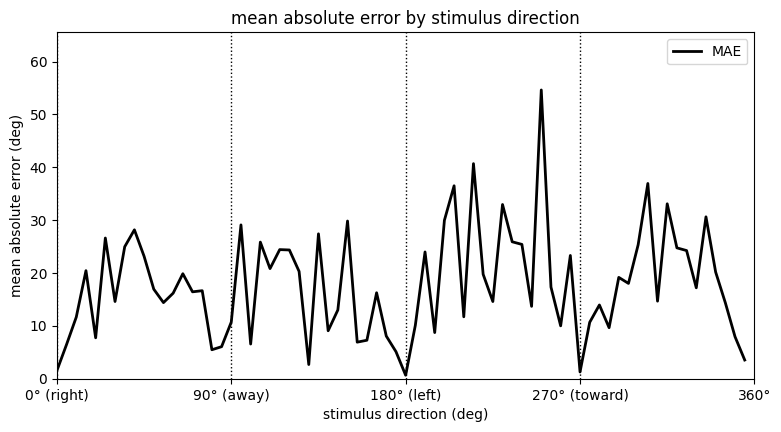

,direction,n_trials,mae
0,0.0,2,1.536252
1,5.0,2,6.492369
2,10.0,2,11.660508
3,15.0,2,20.439642
4,20.0,2,7.739866
...,...,...,...
67,335.0,2,30.621791
68,340.0,2,20.172763
69,345.0,2,14.365531
70,350.0,2,7.946406


In [8]:
mae_results = (
    pd.DataFrame({"direction": stim_direction_3d, "abs_error": error_3d.abs()})
    .groupby("direction", as_index=False)
    .agg(n_trials=("abs_error", "size"), mae=("abs_error", "mean"))
)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(mae_results["direction"], mae_results["mae"], "k-", linewidth=2, label="MAE")
for direction in [0, 90, 180, 270]:
    ax.axvline(direction, color="black", linestyle=":", linewidth=1)
format_mae_axis(ax, "mean absolute error by stimulus direction", mae_results["mae"].max() * 1.2)
ax.legend(loc="best")
plt.show()
display(mae_results)

Are errors larger for lateral directions (right/left) or in-depth directions (away/toward)?

## Part B. Comparison to 2D Motion Direction Estimation

In Lab 7, you estimated the direction of dots moving across a flat screen using the same pointer-based response method. In the 2D task every direction was frontoparallel, with no motion-in-depth component. Here we load those data and compare accuracy across the full 360°.

### Step 1. Load the 2D estimation data

Enter the same participant ID used in Lab 7.

In [9]:
participant_id_2d = "demo"

data_dir_2d = Path("..") / "07-motion-direction" / "2d-motion-direction-estimation" / "data"
file_info_2d = find_participant_files(data_dir_2d, participant_id_2d)
n_files_2d = len(file_info_2d)

data files found:
    "demo_2d-motion-direction-estimation_2025-02-26_22h06.12.747.csv"


**Confirm that your 2D data files are listed above.** There should be one file.

#### Load and merge data tables

In [10]:
# The PsychoPy Builder file has one metadata/instruction row before the trials.
estim2d_data = load_psychopy_csvs(file_info_2d, remove_instruction_rows=True)
n_trials_2d = len(estim2d_data)
print(f"number of 2D trials = {n_trials_2d}")

number of 2D trials = 112


### Step 2. Compute 2D errors

The 2D file stores stimulus direction in `orientation` and the response in `pointer_orientation`. Pointer orientation is a clockwise rotation from up, so convert it to the standard counterclockwise-from-right convention.

In [11]:
stim_direction_2d = estim2d_data["orientation"].astype(float)
response_direction_2d = np.mod(360 - estim2d_data["pointer_orientation"].astype(float), 360)
error_2d = np.mod(response_direction_2d - stim_direction_2d + 180, 360) - 180
mae_results_2d = (
    pd.DataFrame({"direction": stim_direction_2d, "abs_error": np.abs(error_2d)})
    .groupby("direction", as_index=False)
    .agg(n_trials=("abs_error", "size"), mae=("abs_error", "mean"))
)

### Step 3. Compare the data

The final figure compares responses and mean absolute error for both experiments. The shaded regions mark the in-depth directions (away and toward).

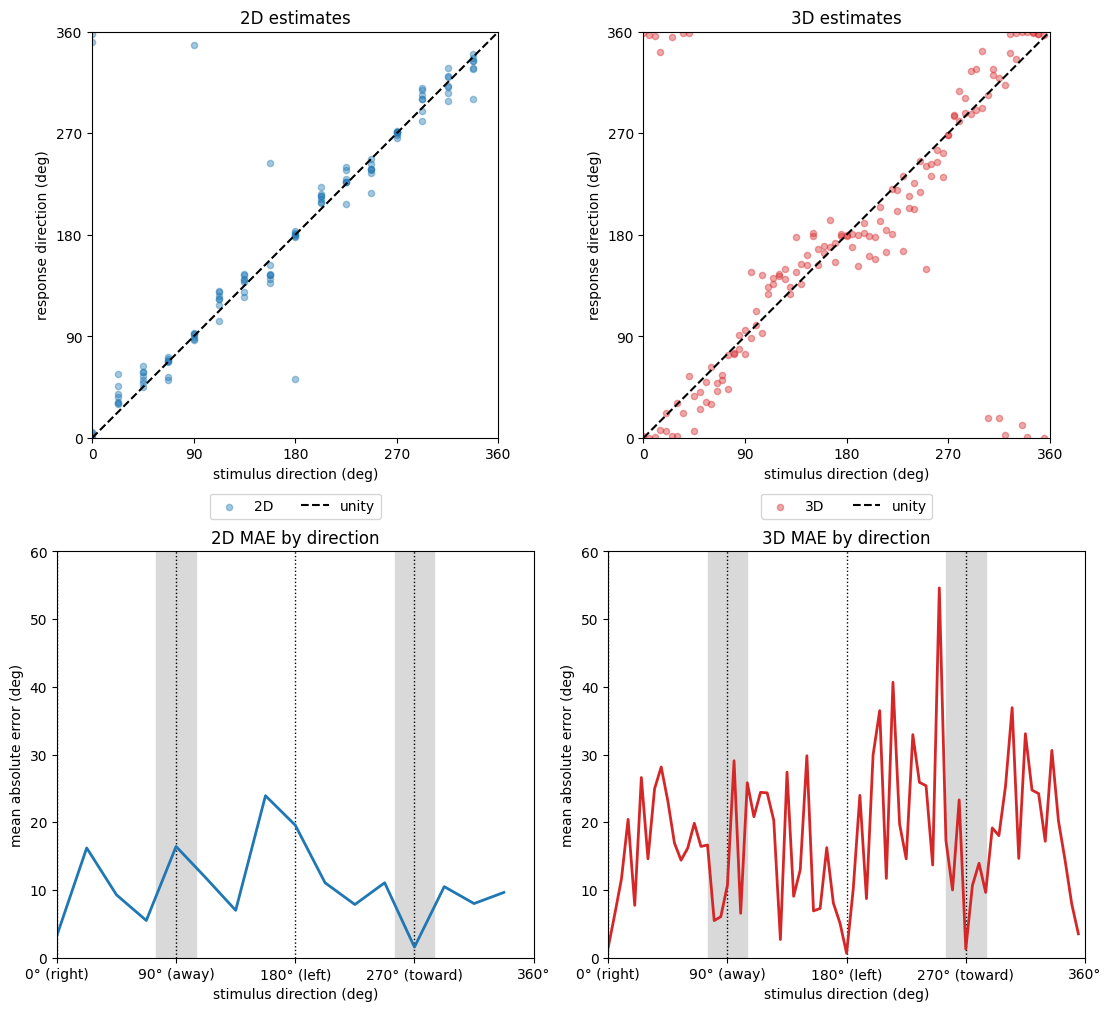

average 2D MAE: 10.79°
average 3D MAE: 17.93°


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10), constrained_layout=True)
for ax, stim, response, color, title in [
    (axes[0, 0], stim_direction_2d, response_direction_2d, "tab:blue", "2D estimates"),
    (axes[0, 1], stim_direction_3d, response_direction_3d, "tab:red", "3D estimates"),
]:
    ax.scatter(stim, response, s=20, color=color, alpha=0.4, label=title[:2])
    ax.plot([0, 360], [0, 360], "k--", linewidth=1.5, label="unity")
    ax.set(xlabel="stimulus direction (deg)", ylabel="response direction (deg)", title=title,
           xlim=(0, 360), ylim=(0, 360))
    ax.set_xticks(np.arange(0, 361, 90)); ax.set_yticks(np.arange(0, 361, 90))
    ax.set_aspect("equal", adjustable="box"); ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2)
for ax, results, color, title in [
    (axes[1, 0], mae_results_2d, "tab:blue", "2D MAE by direction"),
    (axes[1, 1], mae_results, "tab:red", "3D MAE by direction"),
]:
    ax.axvspan(75, 105, color="0.85", zorder=0); ax.axvspan(255, 285, color="0.85", zorder=0)
    for direction in [0, 90, 180, 270]: ax.axvline(direction, color="black", linestyle=":", linewidth=1)
    ax.plot(results["direction"], results["mae"], color=color, linewidth=2)
    format_mae_axis(ax, title, ymax=60)
plt.show()
print(f"average 2D MAE: {mae_results_2d['mae'].mean():.2f}°")
print(f"average 3D MAE: {mae_results['mae'].mean():.2f}°")